In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

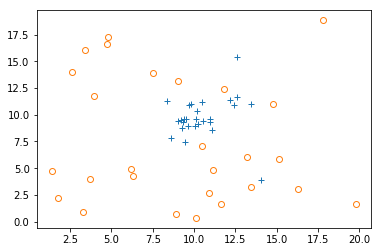

In [2]:
mu, cov = [10, 10], [[1, 0], [0, 1]]

filt = 0.5   #10%
N1 = int(5000*filt/100)
N2 = int(400 *filt/100)
N3 = int(5400*filt/100)

GaussX, GaussY = np.random.multivariate_normal(mu,cov,N1).T
NoiseX, NoiseY = np.random.random((2,N2))*20

NoiseyGaussX, NoiseyGaussY  = np.concatenate((GaussX,NoiseX)), np.concatenate((GaussY,NoiseY))
UniformX,     UniformY      = np.random.random((2,N3))*20

plt.plot(NoiseyGaussX, NoiseyGaussY, '+') 
plt.plot(UniformX,     UniformY,     'o', mfc='none') 

dataC1= np.vstack((NoiseyGaussX, NoiseyGaussY, np.zeros((N3)))).T # add labels
dataC2= np.vstack((UniformX,     UniformY,     np.ones((N3)))).T # add labels

data = np.concatenate((dataC1,dataC2))
df = pd.DataFrame(data,columns=['x1','x2','Class'])



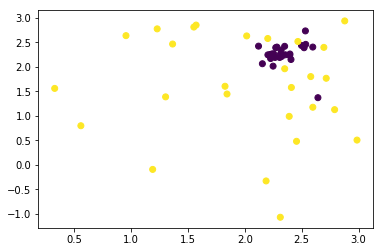

In [3]:
#da
# dataS = data[50:60,:]
# print(dataS)
# plt.scatter(data[:,0],data[:,1],c=data[:,2])
x1 = data[:,0]
x2 = data[:,1]
c  = data[:,2]
#plt.scatter(x1, x2,c=c)
X1 = np.log(x1)#**2-x1
X2 = np.log(x2)#-x2
plt.scatter(X1, X2,c=c)

Generate the Data

In [259]:
N = 15#70 #15

t = np.linspace(0, 2*np.pi, num = N)
a = 0.5
b = 0.5
r = 1
x = a + r * np.cos(t)
y = b + r * np.sin(t)

mx, mn = a-3*r, b+3*r
noise = 0.5*r

Y = np.random.normal(y,noise)
X = np.random.normal(x,noise)

Plot the classes

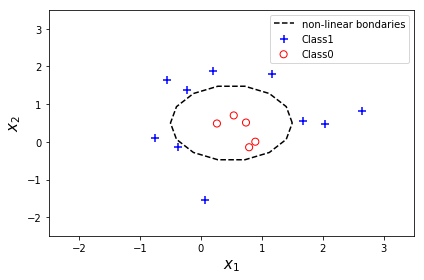

In [263]:
# plot the non-linear separator of the classes
ax = plt.axes()
ax.set_ylim(mx,mn)
ax.set_xlim(mx,mn)
ax.plot(x,y,'--k', label = 'non-linear bondaries')
#plt.plot(X, Y,'.b')

ind0 = (X-a)**2 + (Y-b)**2 <   r**2
ind1 = (X-a)**2 + (Y-b)**2 >=  r**2


C1 = [X[ind1],Y[ind1]]       # Actual Class1
C0 = [X[ind0],Y[ind0]]       # Actual Class0

plt.scatter(C1[0],C1[1], s=50,color='b',    marker='+', label= 'Class1')
plt.scatter(C0[0],C0[1], s=50,color='none', marker='o', label= 'Class0', edgecolor='red')
plt.xlabel('$x_1$', fontsize=15)
plt.ylabel('$x_2$', fontsize=15)
plt.legend()
plt.tight_layout()

data = np.array([X,Y, ind0*1 ])
# print(data)#
# plt.scatter(data[0],data[1], s=200,c=data[2],    marker='+', label= 'Class1')

plt.savefig('figures\FeaturesBeforeMapping.png')

Now mapp the data inot a new space to linearise the classes seprability

In [261]:
# Ok so now let us map to a new space that will make everything linear

X1 = X**2 - 2*a*X                # right hand side of solution     (x1-a)^2 + (x2-b)^2  = r^2
Y1 = Y**2 - 2*b*Y                # right hand side of solution     (x1-a)^2 + (x2-b)^2  = r^2

C1_ = [X1[ind1],Y1[ind1]]        # Actual Class1
C0_ = [X1[ind0],Y1[ind0]]        # Actual Class0

Let us now plot the results of the mapped space

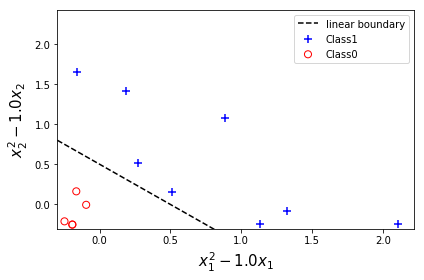

In [262]:
#plt.figure(figsize=(3, 5), dpi=80)


xlim = [np.min(X1)-0.05, np.max(X1)-2.1]
ylim = [np.min(Y1)-0.05, np.max(Y1)-1.5]

plt.xlim(xlim)
plt.ylim(ylim)

plt.scatter(C1_[0],C1_[1], s=50,color='b',    marker='+', label= 'Class1')
plt.scatter(C0_[0],C0_[1], s=50,color='none', marker='o', label= 'Class0', edgecolor='red')

t = np.linspace(xlim[0], xlim[1], num = N)
y2 = -t + r**2-a**2-b**2                         # right hand side of solution x1 (x1-a)^2 + (x2-b)^2  = r^2
plt.plot(t,y2, '--k', label = 'linear boundary') # for the mapped data
plt.xlabel('$x_1^2 - {}x_1$'.format(2*a), fontsize=15)
plt.ylabel('$x_2^2 - {}x_2$'.format(2*b), fontsize=15)
plt.legend()
plt.tight_layout()
#plt.plot(-16,40,'xb',markersize=25)
plt.savefig('figures\FeaturesAftetMapping.png')